#### Imports e Carregamento do dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

file_path = 'binary_beans_english.csv'
df = pd.read_csv(file_path)

#### Inspeção inicial

In [2]:
print("--- Data Before Cleaning ---")
df.info()

--- Data Before Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Length       5975 non-null   float64
 1   Width        5973 non-null   float64
 2   Area         5973 non-null   float64
 3   Perimeter    5970 non-null   float64
 4   Roundness    5969 non-null   float64
 5   Compactness  5977 non-null   float64
 6   Class        5970 non-null   object 
dtypes: float64(6), object(1)
memory usage: 328.3+ KB


#### Análise das Labels

--- Contagem da Variável Alvo ('Class') ---
Class
White Haricot Bean    3779
Mixed Other Beans     2191
Name: count, dtype: int64




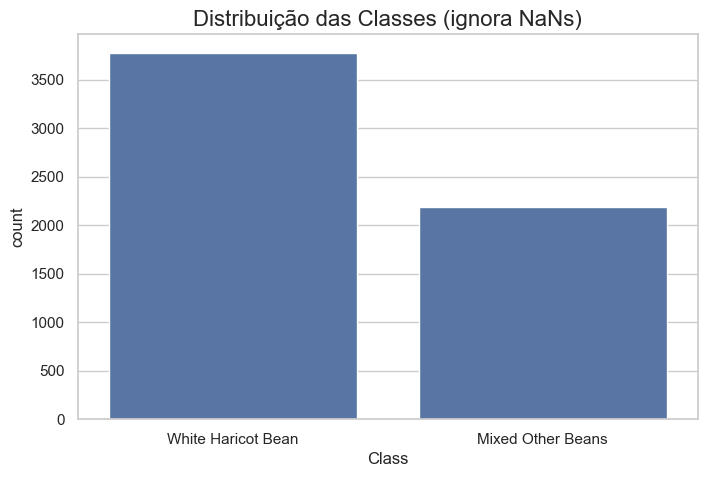

In [3]:
print("--- Contagem da Variável Alvo ('Class') ---")
print(df['Class'].value_counts())
print("\n")

# Plot visual da contagem
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='Class')
ax.set_title("Distribuição das Classes (ignora NaNs)", fontsize=16)
plt.show()

#### Distribuição das Features

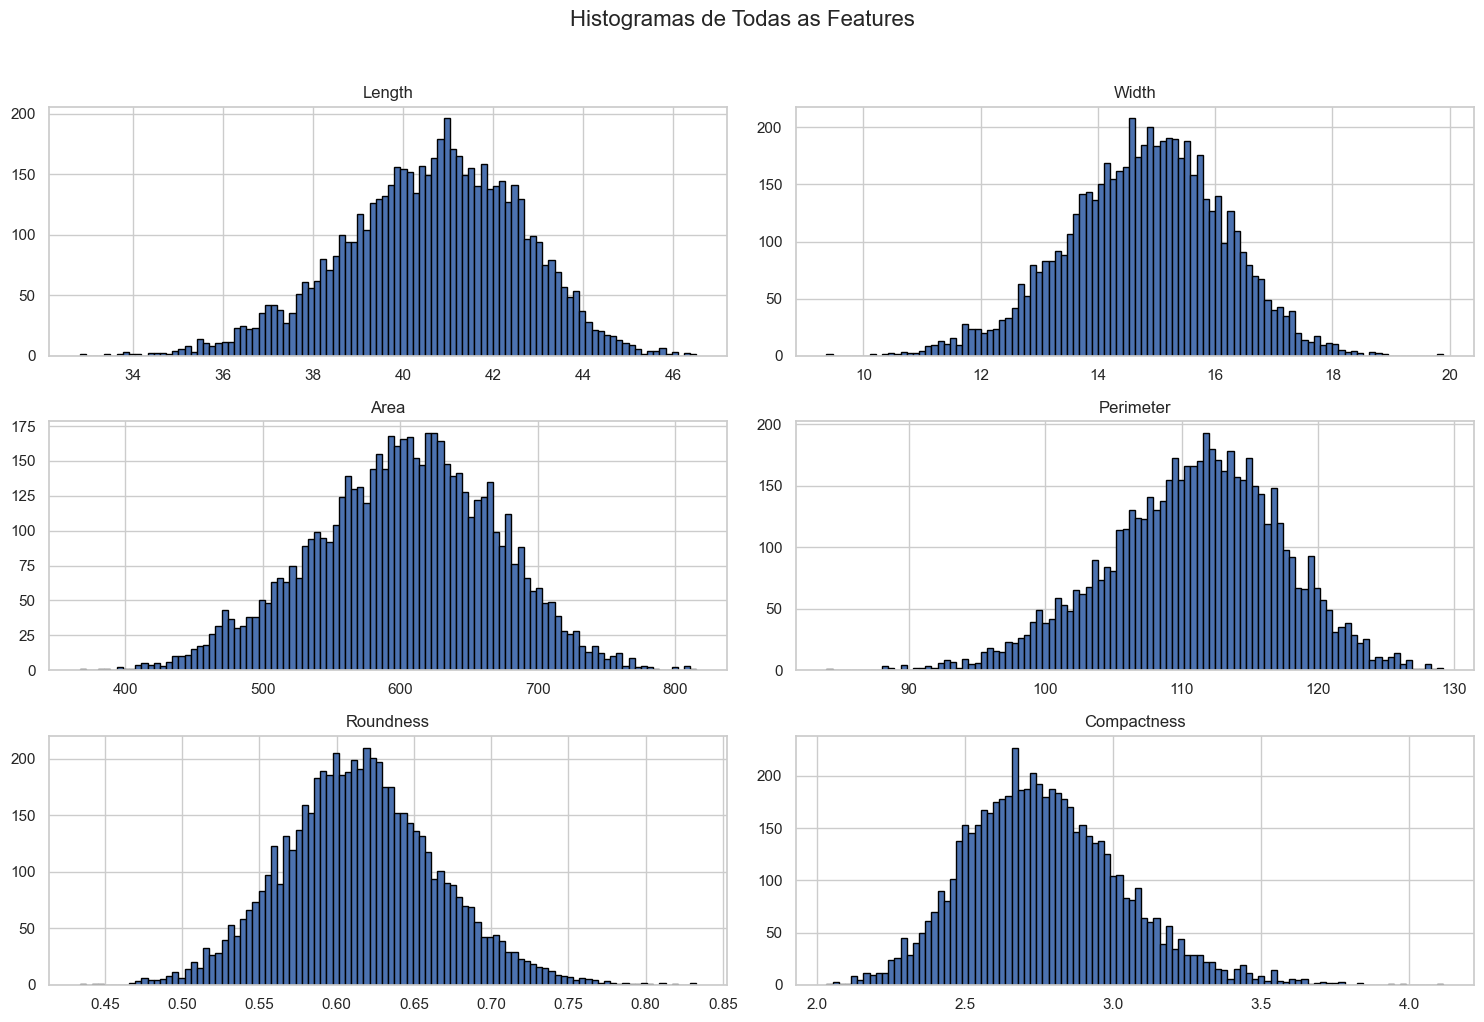

In [4]:
features = ['Length', 'Width', 'Area', 'Perimeter', 'Roundness', 'Compactness']

df[features].hist(figsize=(15, 10), bins=100, edgecolor='black')
plt.suptitle("Histogramas de Todas as Features", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

#### Feature vs Label (Análise Numérica)

In [5]:
print("--- Sumário Estatístico por Classe ---")
estatisticas_por_classe = df.groupby('Class').describe()
print(estatisticas_por_classe.T)

--- Sumário Estatístico por Classe ---
Class              Mixed Other Beans  White Haricot Bean
Length      count        2187.000000         3759.000000
            mean           39.160353           41.512137
            std             1.744974            1.489909
            min            32.818372           36.223198
            25%            38.049458           40.495589
            50%            39.157144           41.499636
            75%            40.287030           42.530719
            max            45.495875           46.520909
Width       count        2179.000000         3764.000000
            mean           14.112545           15.196536
            std             1.353678            1.137787
            min             9.368682           11.057259
            25%            13.155419           14.414640
            50%            14.120176           15.212042
            75%            15.035728           15.968454
            max            18.452117           19

#### Feature vs Label (Boxplots)


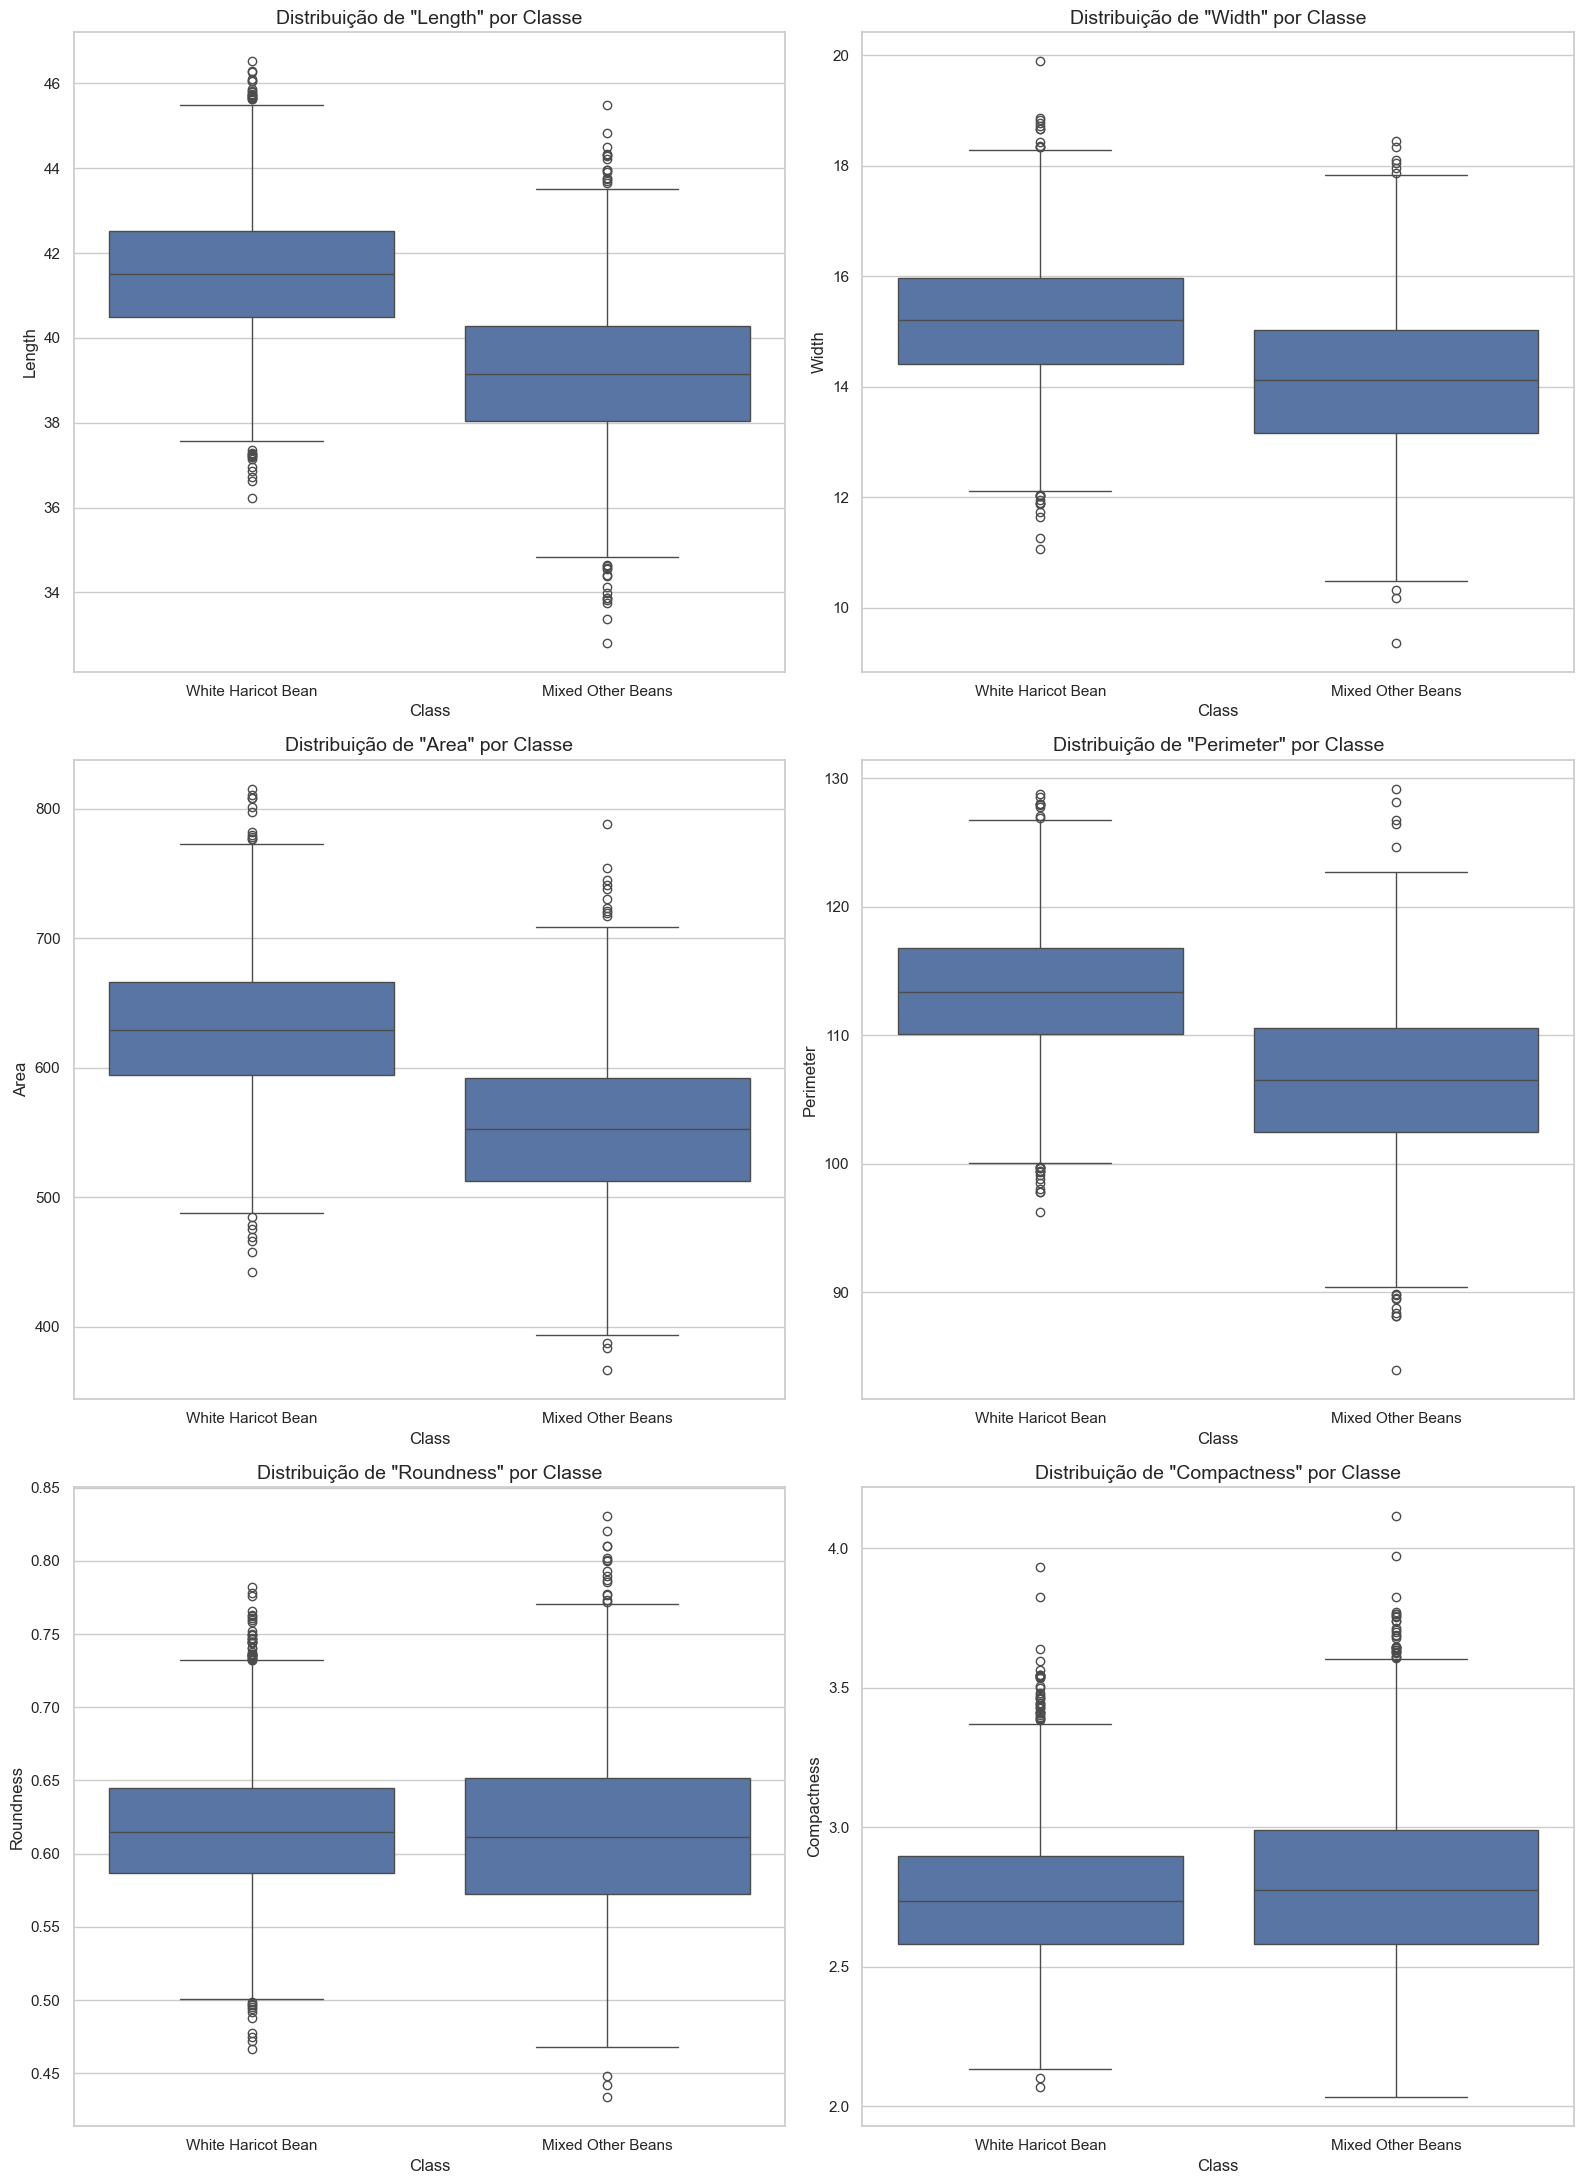

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 22))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='Class', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'Distribuição de "{feature}" por Classe', fontsize=14)

plt.tight_layout() 
plt.show()

#### Feature vs Label (Gráficos de Densidade)



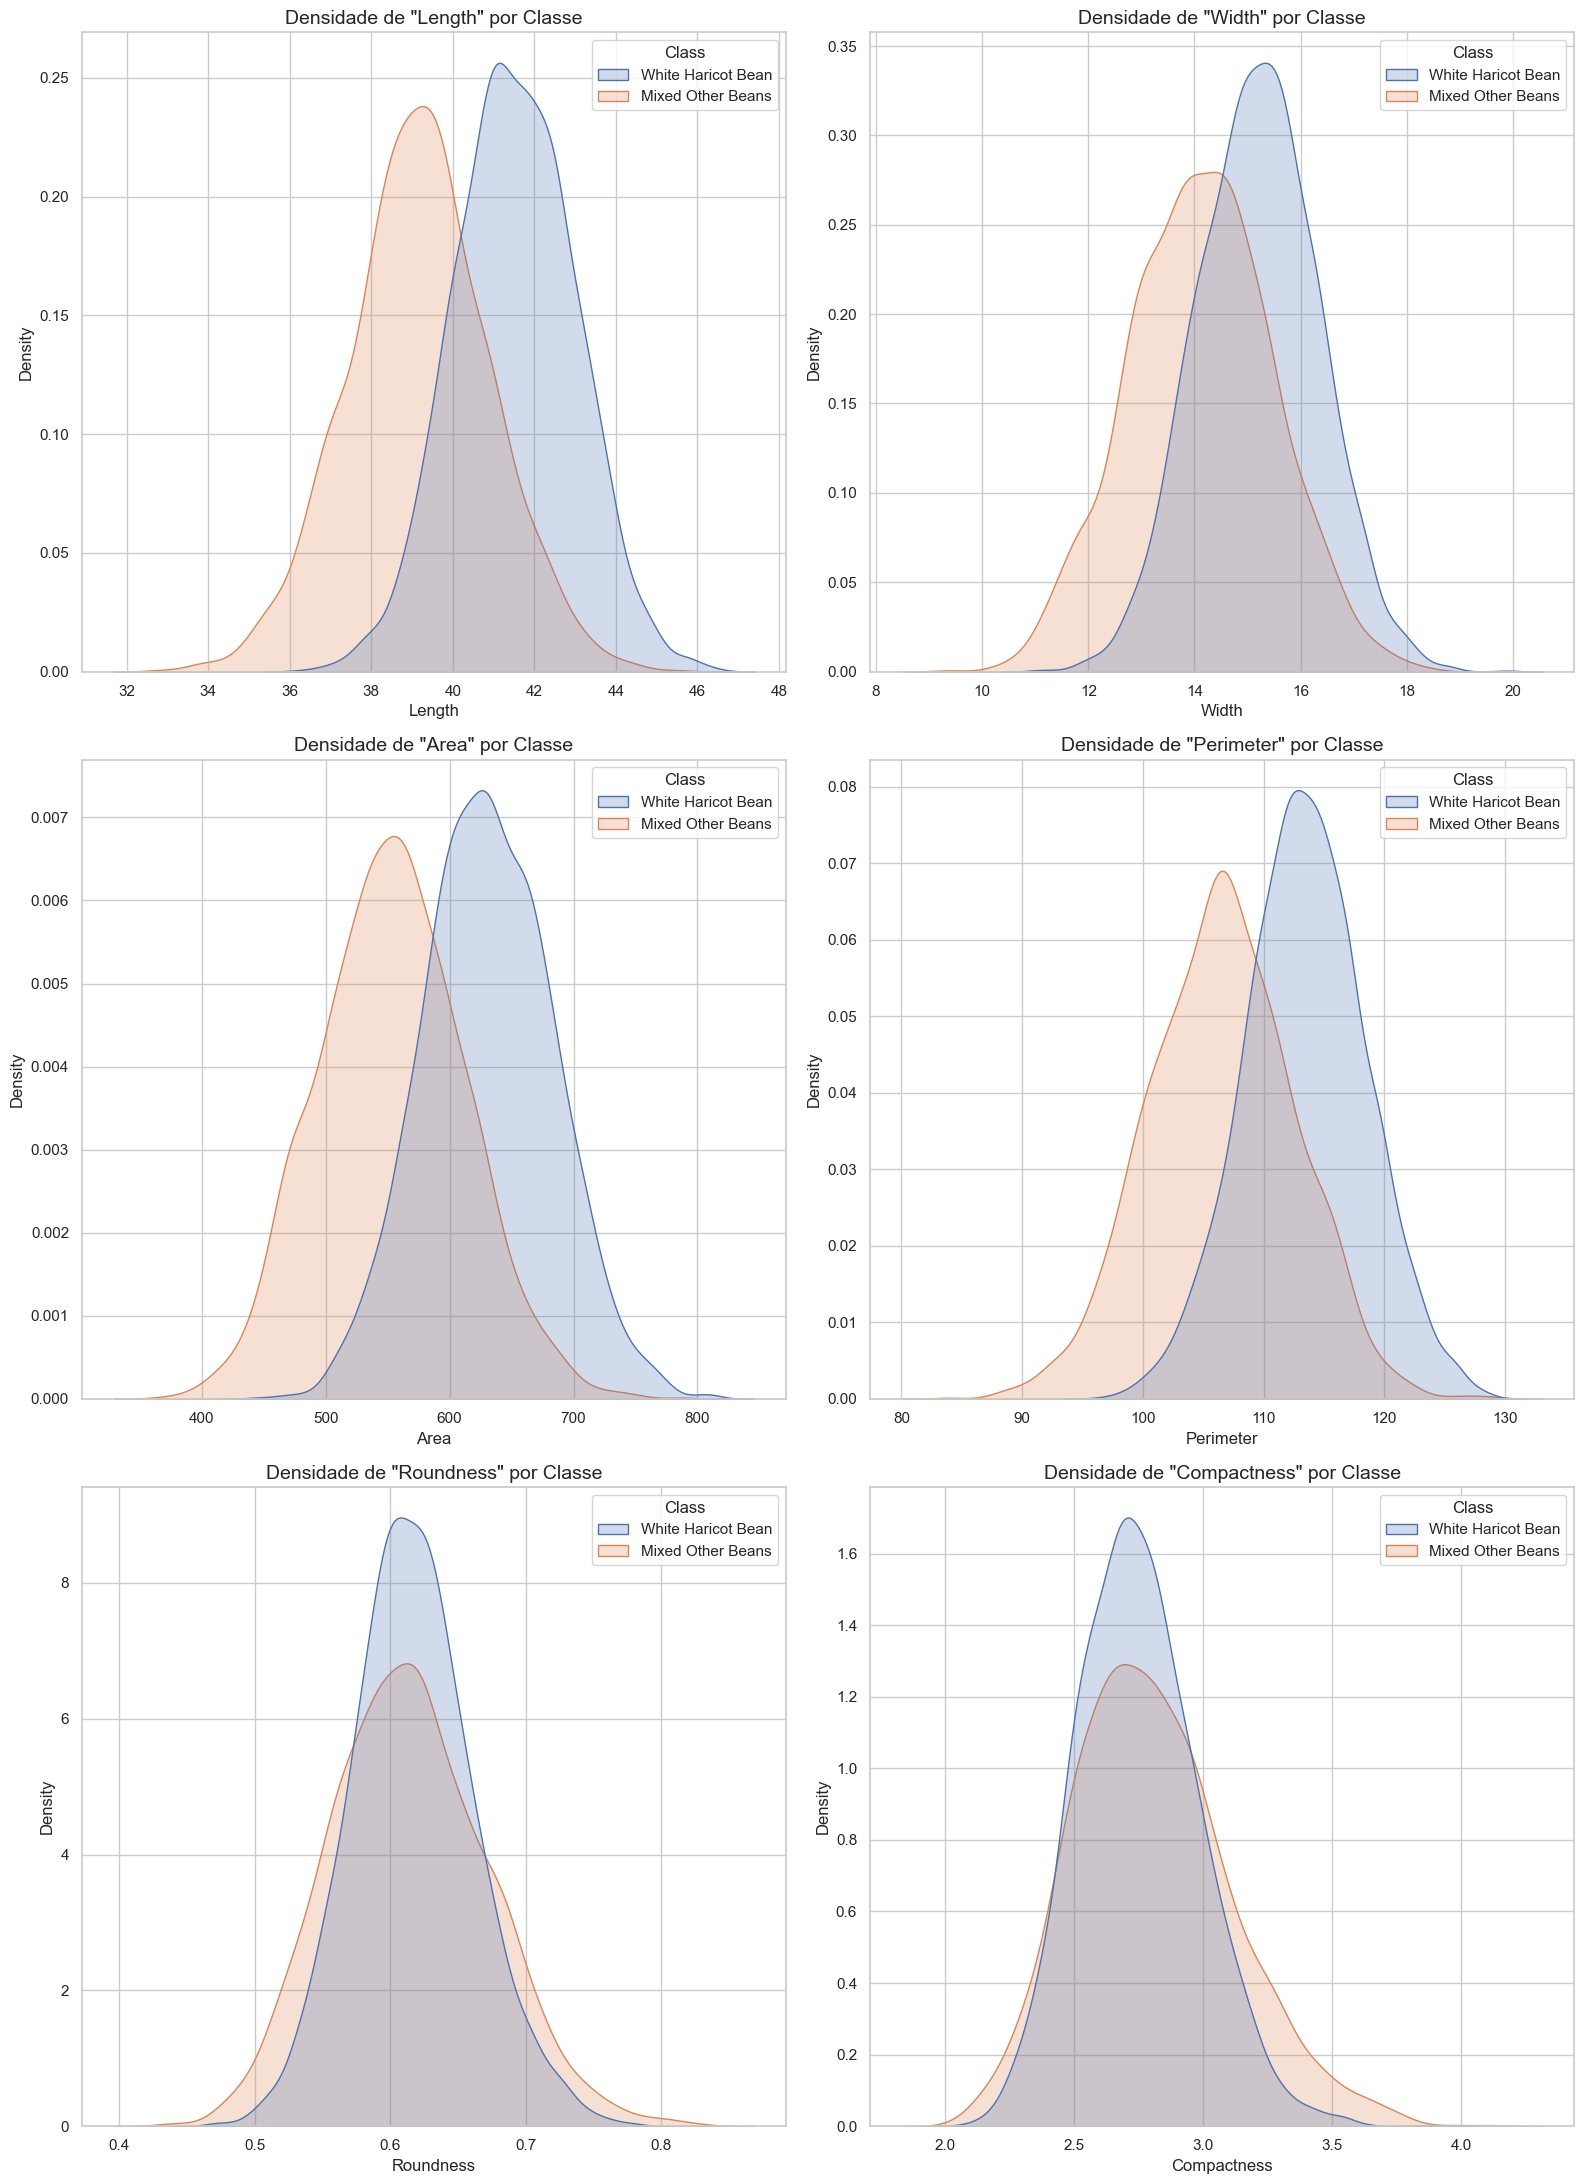

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(16, 22))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.kdeplot(data=df, x=feature, hue='Class', fill=True, 
                common_norm=False, ax=axes[i], legend=True)
    axes[i].set_title(f'Densidade de "{feature}" por Classe', fontsize=14)

plt.tight_layout()
plt.show()

#### Feature vs Feature (Matriz de Correlação)

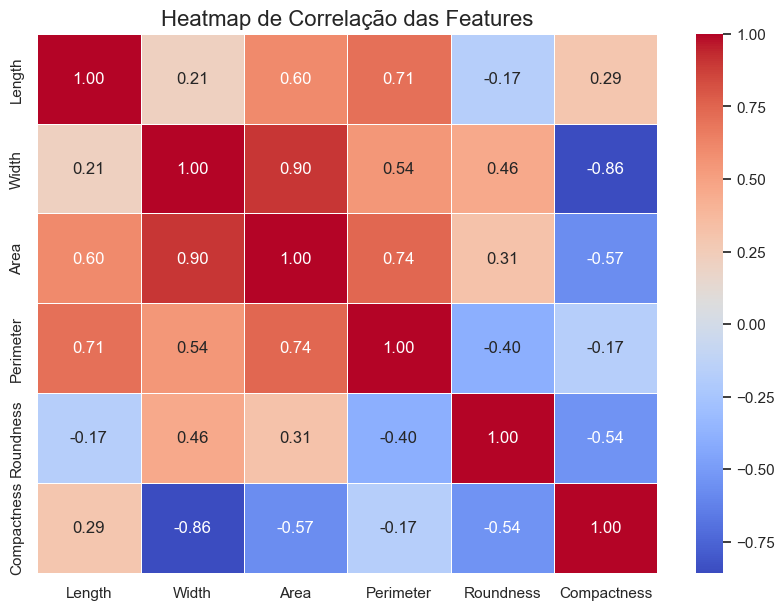

In [8]:
plt.figure(figsize=(10, 7))
corr_matrix = df[features].corr() 
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap de Correlação das Features", fontsize=16)
plt.show()

#### Feature vs Feature (Pairplot)

In [ ]:
sns.pairplot(data=df.dropna(subset=['Class']),
             hue='Class', 
             vars=features)
plt.suptitle("Pairplot de Features por Classe", y=1.02, fontsize=16)
plt.show()